# T11b — LSTM (Long Short-Term Memory)

Uses `deep_learning.py` for all shared setup, training and evaluation.

**Model:** LSTM — adds a cell state to handle long-range dependencies. Standard go-to for CMAPSS in the literature.

In [1]:
import sys
from pathlib import Path
_root = next(p for p in Path().resolve().parents if (p / "src").exists())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
ROOT = _root


In [2]:
from src.models.deep_learning import *
import torch.nn as nn

print(f"Device: {DEVICE}")

Device: mps


## 1. Load data & build windows

In [3]:
train_df, test_df = load_data()
FEAT_COLS  = select_features(train_df)
N_FEATURES = len(FEAT_COLS)

X_train, y_train, X_val, y_val = engine_split(train_df, FEAT_COLS)
X_test, y_test = build_windows(test_df, FEAT_COLS, is_test=True)

train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test
)


Train shape : (61249, 123)  (249 engines)
Test  shape : (41214, 123)   (248 engines)
Feature columns (48): ['s2_rmean_5', 's3_rmean_5', 's4_rmean_5', 's6_rmean_5', 's7_rmean_5'] ...
Train engines: 199  Val engines: 50
X_train: (43750, 30, 48)  X_val: (50, 30, 48)
Train batches: 342  Val batches: 1


## 2. Model definition

LSTM — forget gate + input gate + cell state allow it to learn what to remember across long sequences.

In [4]:
from src.models.dl_architectures import LSTMModel


## 3. Train

In [ ]:
model, train_losses, val_losses = train_model(
    model        =,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = EPOCHS,
    model_name   = "LSTM",
)


AttributeError: 'torch.device' object has no attribute '_apply'

## 4. Evaluate

In [ ]:
from src.evaluation.metrics import evaluate

y_true, y_pred = predict_test(model, test_loader)
results = evaluate(y_true, y_pred, model_name="LSTM")
print(results)

  [LSTM] RMSE: 20.2857  |  NASA Score: 1814.37 (mean: 7.32)  |  R2: 0.7772  |  Bias: -7.80 (early ↓)
{'rmse': 20.285741806030273, 'nasa_score': 1814.3653564453125, 'nasa_score_mean': 7.3159893405052925, 'r2_score': 0.7772459387779236, 'bias': -7.796376705169678}


## 5. Plots

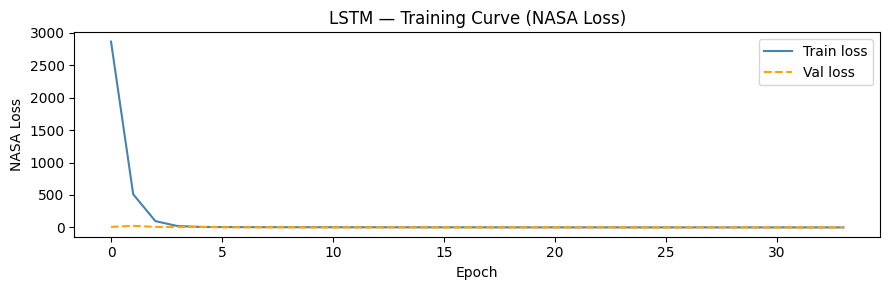

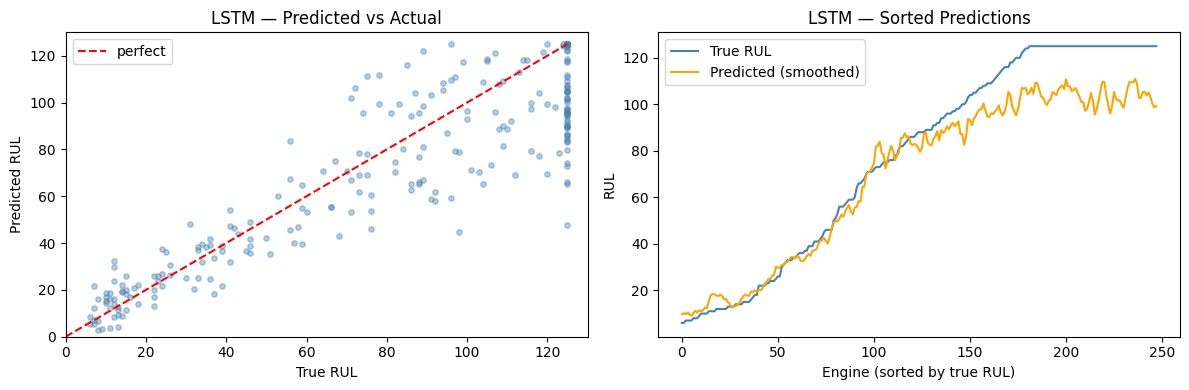

In [ ]:
plot_loss_curves(train_losses, val_losses, model_name="LSTM")
plot_predictions(y_true, y_pred, model_name="LSTM")
